# REGRESSÃO LOGÍSTICA BINÁRIA COM STEPWISE

A Regressão Logística Binária com Stepwise é usada para prever a probabilidade de um evento ocorrer,
selecionando automaticamente as variáveis mais importantes para o modelo. Neste exemplo, vamos analisar
o risco de falha em lançamentos espaciais com base na temperatura.

Aqui está a explicação em 3 pontos simples:

   1. O Objetivo: Prever a probabilidade de falha (sim/não) com base em variáveis explicativas.
   2. A Seleção Stepwise: O algoritmo testa combinações de variáveis e mantém apenas aquelas
      que melhor explicam o evento.
   3. A Previsão: Com o modelo final, podemos estimar a probabilidade de falha para novas condições.

   A fórmula básica que você verá no notebook é:
   P(y=1) = 1 / (1 + e^-(α + βX))
    * P: Probabilidade do evento ocorrer.
    * e: Número de Euler (~2.718).
    * α e β: São os números que o modelo aprende para ajustar a curva.

   Em resumo: é usar uma curva em S para prever probabilidades, selecionando as melhores variáveis para explicar o evento.
</markdown_cell>



#### EXEMPLO 2 - Previsão de falha em lançamentos espaciais


1 - Importação dos pacotes
</markdown_cell>



In [3]:
import pandas as pd # manipulação de dados em formato de dataframe
import numpy as np # operações matemáticas
import seaborn as sns # visualização gráfica
import matplotlib.pyplot as plt # visualização gráfica
from scipy.interpolate import UnivariateSpline # curva sigmoide suavizada
import statsmodels.api as sm # estimação de modelos
from statstests.process import stepwise # procedimento Stepwise
from scipy import stats # estatística chi2
import plotly.graph_objects as go # gráficos 3D
from statsmodels.iolib.summary2 import summary_col # comparação entre modelos
from statsmodels.discrete.discrete_model import MNLogit # estimação do modelo
                                                        #logístico multinomial

import warnings
warnings.filterwarnings("ignore")

2 - Carregando Dados
</markdown_cell>



In [4]:
# CARREGAMENTO DA BASE DE DADOS
df_challenger = pd.read_csv('challenger.csv', delimiter=',')
df_challenger

# Características das variáveis do dataset
df_challenger.info()

# Estatísticas univariadas
df_challenger.describe()

# desgaste: quantidade de vezes em que ocorreu stress térmico
# temperatura: temperatura de lançamento (graus ºF)
# pressão: pressão de verificação de vazamento (psi: libra-força por
    #polegada ao quadrado)
# t: teste para o lançamento (id)

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   desgaste     23 non-null     int64
 1   temperatura  23 non-null     int64
 2   pressão      23 non-null     int64
 3   t            23 non-null     int64
dtypes: int64(4)
memory usage: 868.0 bytes


,desgaste,temperatura,pressão,t
count,23.000000,23.000000,23.000000,23.00000
mean,0.304348,69.565217,152.173913,12.00000
std,0.558796,7.057080,68.221332,6.78233
min,0.000000,53.000000,50.000000,1.00000
25%,0.000000,67.000000,75.000000,6.50000
50%,0.000000,70.000000,200.000000,12.00000
75%,0.500000,75.000000,200.000000,17.50000
max,2.000000,81.000000,200.000000,23.00000


2.1 - Criação da variável dependente binária
</markdown_cell>



In [5]:
# Criação da variável dependente binária "falha"
df_challenger.loc[df_challenger['desgaste'] != 0, 'falha'] = 1
df_challenger.loc[df_challenger['desgaste'] == 0, 'falha'] = 0

# Transformando a variável 'falha' para o tipo int
df_challenger['falha'] = df_challenger['falha'].astype('int64')

df_challenger.info()
df_challenger

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   desgaste     23 non-null     int64
 1   temperatura  23 non-null     int64
 2   pressão      23 non-null     int64
 3   t            23 non-null     int64
 4   falha        23 non-null     int64
dtypes: int64(5)
memory usage: 1.0 KB


,desgaste,temperatura,pressão,t,falha
0,0,66,50,1,0
1,1,70,50,2,1
2,0,69,50,3,0
3,0,68,50,4,0
4,0,67,50,5,0
5,0,72,50,6,0
6,0,73,100,7,0
7,0,70,100,8,0
8,1,57,200,9,1
9,1,63,200,10,1


2.2 - Visualização das variáveis explicativas
</markdown_cell>



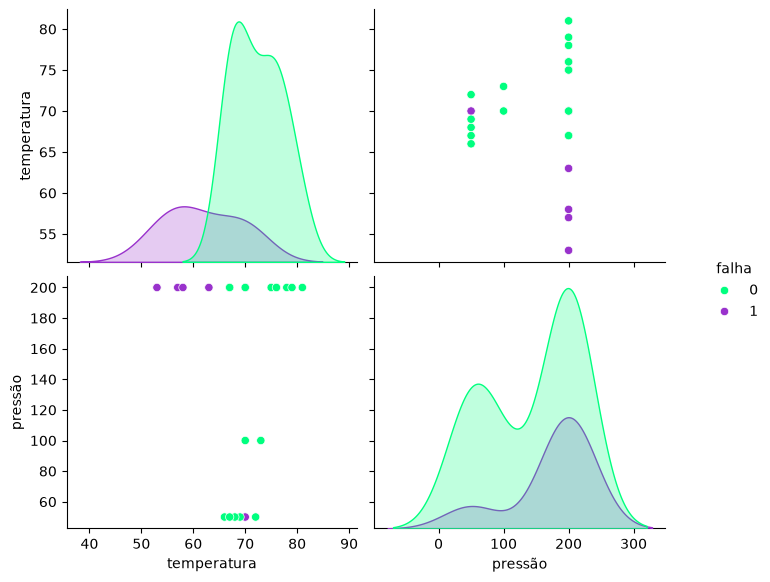

In [6]:
# Gráfico pairplot com scatters e KDEs por falha

cores_desejadas = {0: "springgreen", 1: "darkorchid"}

g = sns.pairplot(df_challenger[["falha", "temperatura", "pressão"]], hue="falha",
                 palette=cores_desejadas)
g.fig.set_size_inches(8, 6)
plt.show()

3 - Gráfico de dispersão com o ajuste logístico
</markdown_cell>



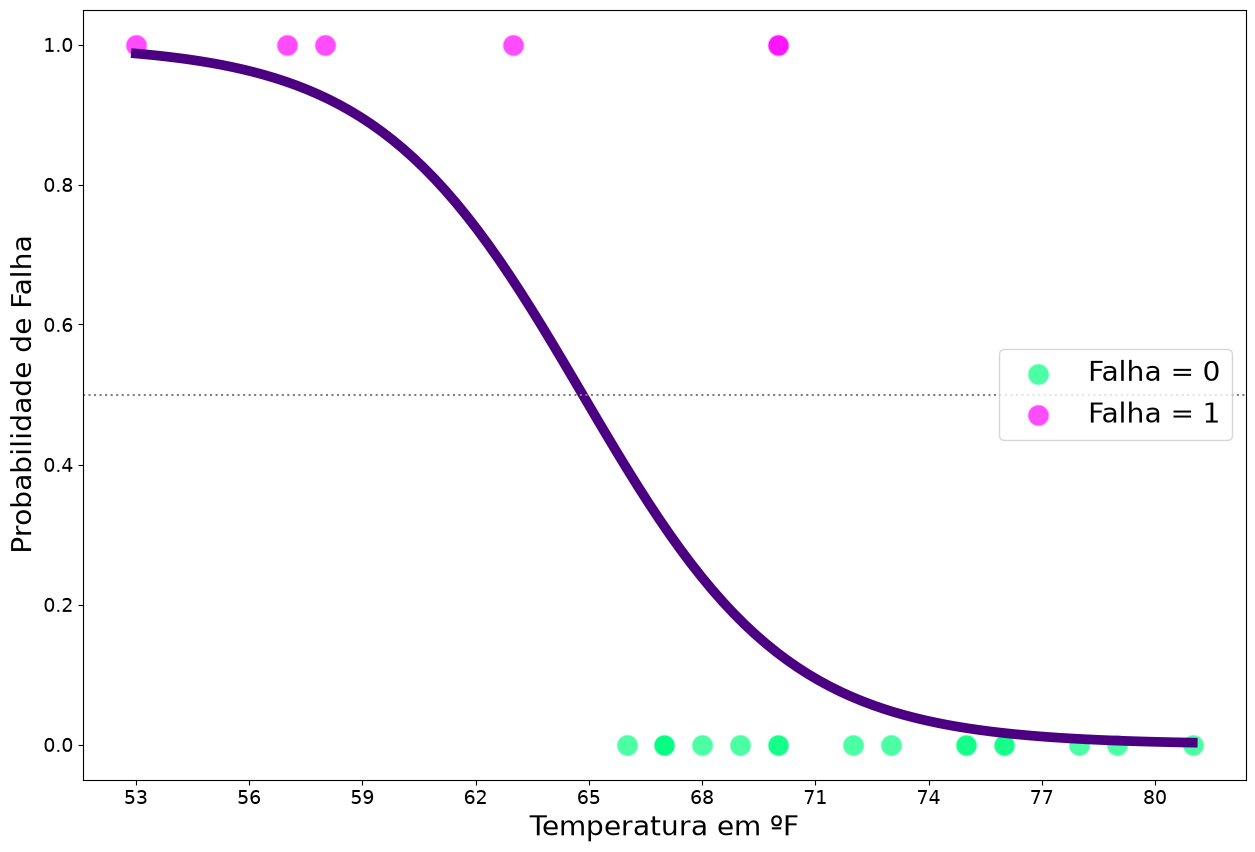

In [7]:
# Construção da sigmoide - Probabilidade de evento em função da variável temperatura

plt.figure(figsize=(15,10))
sns.scatterplot(x=df_challenger["temperatura"][df_challenger["falha"] == 0],
                y=df_challenger["falha"][df_challenger["falha"] == 0],
                color="springgreen", alpha=0.7, s=250, label="Falha = 0")
sns.scatterplot(x=df_challenger["temperatura"][df_challenger["falha"] == 1],
                y=df_challenger["falha"][df_challenger["falha"] == 1],
                color="magenta", alpha=0.7, s=250, label="Falha = 1")
sns.regplot(x=df_challenger["temperatura"], y=df_challenger["falha"],
            logistic=True, ci=None, scatter=False,
            line_kws={'color': 'indigo', 'linewidth': 7})
plt.axhline(y=0.5, color="grey", linestyle=":")
plt.xlabel("Temperatura em ºF", fontsize=20)
plt.ylabel("Probabilidade de Falha", fontsize=20)
plt.xticks(np.arange(df_challenger["temperatura"].min(),
                     df_challenger["temperatura"].max() + 0.01, 3),
           fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.legend(fontsize=20, loc="center right")
plt.show()

4 - Estimação do modelo logístico binário
</markdown_cell>



In [8]:
# Estimação do modelo
modelo_challenger = sm.Logit.from_formula('falha ~ temperatura + pressão', df_challenger).fit()

Optimization terminated successfully.
         Current function value: 0.305063
         Iterations 8


4.1 - Observação dos parâmetros resultantes da estimação
</markdown_cell>



In [9]:
print(modelo_challenger.summary())

                           Logit Regression Results                           
Dep. Variable:                  falha   No. Observations:                   23
Model:                          Logit   Df Residuals:                       20
Method:                           MLE   Df Model:                            2
Date:                Mon, 14 Sep 2026   Pseudo R-squ.:                  0.4685
Time:                        22:32:29   Log-Likelihood:                -7.0164
converged:                       True   LL-Null:                       -13.201
Covariance Type:            nonrobust   LLR p-value:                  0.002061
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      21.8436     11.936      1.830      0.067      -1.551      45.239
temperatura    -0.3501      0.173     -2.024      0.043      -0.689      -0.011
pressão         0.0060      0.010      0.616    

4.2 - Procedimento Stepwise
</markdown_cell>



In [10]:
# Procedimento Stepwise para seleção de variáveis
step_challenger = stepwise(modelo_challenger, pvalue_limit=0.05)

Regression type: Logit 

Estimating model...: 
 falha ~ Q('temperatura') + Q('pressão')
Optimization terminated successfully.
         Current function value: 0.305063
         Iterations 8

 Discarding atribute "Q('pressão')" with p-value equal to 0.5378022290437208 

Estimating model...: 
 falha ~ Q('temperatura')
Optimization terminated successfully.
         Current function value: 0.313604
         Iterations 8

 No more atributes with p-value higher than 0.05

 Atributes discarded on the process...: 

{'atribute': "Q('pressão')", 'p-value': np.float64(0.5378022290437208)}

 Model after stepwise process...: 
 falha ~ Q('temperatura') 

                           Logit Regression Results                           
Dep. Variable:                  falha   No. Observations:                   23
Model:                          Logit   Df Residuals:                       21
Method:                           MLE   Df Model:                            1
Date:                Mon, 14 Sep 20

4.3 - Observação dos parâmetros resultantes do Stepwise
</markdown_cell>



In [11]:
step_challenger.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  falha   No. Observations:                   23
Model:                          Logit   Df Residuals:                       21
Method:                           MLE   Df Model:                            1
Date:                Mon, 14 Sep 2026   Pseudo R-squ.:                  0.4536
Time:                        22:32:29   Log-Likelihood:                -7.2129
converged:                       True   LL-Null:                       -13.201
Covariance Type:            nonrobust   LLR p-value:                 0.0005387
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           23.7750     11.820      2.011      0.044       0.607      46.943
Q('temperatura')    -0.3667      0.175     -2.093      0.036      -0.710      -0.023
====================================================================================
"""

# Análise da Regressão Logística Binária com Stepwise

## Resumo do Modelo

O objetivo deste modelo é prever a probabilidade de falha em lançamentos espaciais
com base em variáveis como temperatura e pressão. O procedimento Stepwise foi utilizado
para selecionar automaticamente as variáveis mais relevantes para o modelo final.

### Equação Logística

[
P(falha=1) = 1 / (1 + e^-(α + β₁×temperatura + β₂×pressão))
]

Onde:

* **Intercepto (α):** Valor base quando as variáveis explicativas são zero.
* **Coeficiente da Temperatura (β₁):** Impacto da temperatura na probabilidade de falha.
* **Coeficiente da Pressão (β₂):** Impacto da pressão na probabilidade de falha.

---

# Interpretação dos Coeficientes

Os coeficientes da regressão logística estão em log-odds (logit). Para interpretar como probabilidades,
precisamos converter para odds usando e^β e depois para probabilidades.

---

# Seleção de Variáveis com Stepwise

O Stepwise testa diferentes combinações de variáveis e mantém apenas aquelas que contribuem
significativamente para o modelo, usando o critério de p-valor definido pelo usuário.

---

# Qualidade do Ajuste

## Log-Likelihood

O log-likelihood mede a probabilidade dos dados dado o modelo. Valores mais próximos de zero indicam melhor ajuste.

## Pseudo R² (McFadden)

Diferente do R² da regressão linear, o pseudo R² da regressão logística mede a melhora do modelo em relação ao modelo nulo (sem variáveis).

---

# Significância do Modelo

## Teste Likelihood Ratio

O teste LR compara o modelo com e sem as variáveis explicativas. Um p-valor baixo indica que as variáveis contribuem significativamente para o modelo.

---

# Previsões com o Modelo Final

## Probabilidades previstas para o dataset



In [12]:
df_challenger['phat'] = step_challenger.predict()
df_challenger
</code_cell>


SyntaxError: invalid syntax (1071968762.py, line 3)

## Exemplos de previsões individuais

Qual a probabilidade de falha a 70ºF?



In [ ]:
step_challenger.predict(pd.DataFrame({'temperatura':[70]}))
</code_cell>

Qual a probabilidade de falha a 77ºF?


In [ ]:
step_challenger.predict(pd.DataFrame({'temperatura':[77]}))
</code_cell>

Qual a probabilidade de falha a 34ºF?


In [ ]:
step_challenger.predict(pd.DataFrame({'temperatura':[34]}))
</code_cell>


---

# Interpretação das Previsões

As previsões do modelo indicam a probabilidade de falha para diferentes temperaturas.
Valores próximos de 1 indicam alta probabilidade de falha, enquanto valores próximos de 0 indicam baixa probabilidade.

---

# Resumo: Regressão Logística Binária com Stepwise

Este documento apresenta um resumo do fluxo de código do notebook, focado na análise da relação entre
**Temperatura**, **Pressão** e **Falha** em lançamentos espaciais.

---

## 1. Preparação e Exploração
- **Objetivo:** Prever a probabilidade de falha com base nas condições de lançamento.
- **Dados:** O arquivo `challenger.csv` é carregado.
- **Análise Inicial:** Uso de `describe()` para estatísticas descritivas e `info()` para verificar tipos de dados.

## 2. Criação da Variável Dependente
- A variável binária "falha" é criada com base na ocorrência de desgastes de peças.
- Falha = 1 quando há desgaste, Falha = 0 quando não há desgaste.

## 3. Visualização Inicial
- É gerado um gráfico de dispersão com uma curva logística usando `seaborn.regplot(logistic=True)`.
- Isso permite visualizar se os pontos seguem uma tendência não linear (curva em S).

## 4. Construção do Modelo
O modelo de **Logística Binária** é estimado:
```python
modelo_challenger = sm.Logit.from_formula("falha ~ temperatura + pressão", df_challenger).fit()
```
- A fórmula indica que a falha depende da temperatura e da pressão.
- O `fit()` faz o computador encontrar os melhores números para a curva logística.

## 5. Seleção Stepwise
- O Stepwise seleciona automaticamente as variáveis mais relevantes para o modelo final.
- O critério utilizado é o p-valor, com limite de 0,05.

## 6. Interpretação dos Resultados
Ao rodar `step_challenger.summary()`, obtemos:
- **Coeficientes:** Indicam como cada variável afeta o log-odds de falha.
- **P-value:** Como é menor que 0,05, a variável é estatisticamente significativa para prever a falha.

## 7. Previsões
O código salva os resultados individuais no DataFrame:
- **phat:** A probabilidade prevista de falha para cada observação.
- **Previsões individuais:** Probabilidades de falha para diferentes temperaturas.

---
**Conclusão do Notebook:** O modelo logístico com Stepwise é utilizado para prever a probabilidade de falha com base nas variáveis mais relevantes.
</markdown_cell>
